<a href="https://colab.research.google.com/github/fl0risk/MNTF_Project/blob/main/MNTF_Floris_Koster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
#import packages
import numpy as np
#import scipy.stats as scipy
#from scipy.stats import norm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


First, we define the Euler-Scheme to generate paths of processes given by SDE's. In particular, we define a 2-dimensional Euler-Scheme. This 2-dimensionality is used in the generating process for the **Heston model**.

In [128]:
def euler_scheme(T, dt, R,second_true,x0,drift_x,vol1_x,W1,
                    drift_y =  lambda x,y,t: 0,vol1_y =  lambda x,y,t: 0,vol2_x = lambda x,y,t: 0,vol2_y =  lambda x,y,t: 0,y0 =  None,W2 = None):
  """
  Performs the Euler scheme for a 2D SDE.
  Args:
    T: The final time.
    dt: The time step.
    R: number of generated paths
    second_true: bool if false only one SDE
    x0: The initial value of x.
    driftx: A vector field representing the drift term in Eq.1.
    drifty: A vector field representing the drift term in Eq.2.
    vol1_x: Integrand of dW_1 in the noise term (volatility) in Eq.1.
    W1: R Brownian motion paths for first SDE
    vol2_x: Integrand of dW_1 in the noise term (volatility) in Eq.2.
    vol1_y: Integrand of dW_2 in the noise term (volatility) in Eq.1.
    vol2_y: Integrand of dW_2 in the noise term (volatility) in Eq.2.
    y0: The initial value of y.
    W2: R Brownian motion paths for second SDE
  Returns:
    A tuple containing the time points, x values, and y values.
  """
  N = int(T / dt)
  t = np.linspace(0, T, N+ 1)
  x = np.zeros((R,N+ 1))
  y = np.zeros((R,N+ 1))
  x[:,0] = x0
  if second_true:
    y[:,0] = y0
  for i in range(N):
    if second_true:
      x[:,i + 1] = np.maximum(x[:,i] + drift_x(x[:,i], y[:,i], t[i]) * dt + vol1_x(x[:,i], y[:,i], t[i]) * (W1[:,i+1]-W1[:,i]) + vol1_y(x[:,i], y[:,i], t[i]) * (W2[:,i+1]-W2[:,i]), 0)
      y[:,i + 1] = np.maximum(y[:,i] + drift_y(x[:,i], y[:,i], t[i]) * dt + vol2_x(x[:,i], y[:,i], t[i]) *  (W1[:,i+1]-W1[:,i]) + vol2_y(x[:,i], y[:,i], t[i]) * (W2[:,i+1]-W2[:,i]), 0)
    else:
      x[:,i + 1] = np.maximum(x[:,i] + drift_x(x[:,i], t[i]) * dt + vol1_x(x[:,i], t[i]) * (W1[:,i+1]-W1[:,i]),0)
  return t, x, y


Before continuing with the implementation of the different price model, we first provide the dynamics for each model.
The **Black-Scholes model** is given by the dynamics
$$\mathrm{d}S_t = \mu S_t\mathrm{d}t + \sigma S_t\mathrm{d}W_t, \; S_0 = 1$$

The **Heston models** dynamics is described by the coupled SDEs:
$$
\begin{aligned}
\mathrm{d}S_t &= \mu S_t\mathrm{d}t + \sqrt{\nu_t}S_t\mathrm{d}W_t^{(1)}, \; S_0 = 1 \\
\mathrm{d}\nu_t &= k(\theta - \nu_t)\mathrm{d}t + \xi \sqrt{\nu_t}\mathrm{d}W_t^{(2)}, \; \nu_0 = 0.2
\end{aligned}
$$
where $\mathrm{d}W_t^{(1)}$ and $\mathrm{d}W_t^{(2)}$ are Brownian motions with correlation $\rho$, $\theta$ denotes the long-term variance and $k$ is the rate of reversion.

The **CEV (Constant Elasticity of Variance) model** is given by
$$\mathrm{d}S_t = \mu S_t\mathrm{d}t + \sigma S_t^{\gamma}\mathrm{d}W_t, S_0 = 1$$
where $\gamma>0$ is the elasticity parameter.

In addition to the risky asset, we assume the existence of a risk-free bank account (or bond) with deterministic dynamics
$$\mathrm{d}B_t = rB_t\mathrm{d}t, \; B_0 = 1,$$
where $r$ is the constant risk-free rate.

Our wealth process $X = (X_t)_{t \ge 0}$ evolves according to the chosen trading strategy $\alpha = (\alpha_t)_{t \ge 0}$, where $\alpha_t$ denotes the proportion of wealth invested in the risky asset at time $t$. The remaining wealth is invested in the risk-free asset. The wealth dynamics are given by
$$
\mathrm{d}X_t =  \alpha_t X_t\frac{\mathrm{d}S_t}{S_t} + (1-\alpha_t)X_t r\mathrm{d}t
$$
where $S_t$ is the price of the risky asset, modelled using one of the above models and $X_0 = 1$.

Using Itô's formula and the above dynamics for the price models we get the following SDE's that are later used in the forward method of our neural networks
\begin{aligned}
\textbf{BS: } \mathrm{d}\log(X_t) &= \alpha_t \frac{\mathrm{d}S_t}{S_t} + (1-\alpha_t)r\mathrm{d}t - \frac{1}{2} \alpha_t^2\sigma^2\mathrm{d}t; \\
\textbf{Heston: } \mathrm{d}\log(X_t) &= \alpha_t \frac{\mathrm{d}S_t}{S_t} + (1-\alpha_t)r\mathrm{d}t - \frac{1}{2} \alpha_t^2\nu_t\mathrm{d}t; \\
\textbf{CEV: } \mathrm{d}\log(X_t) &= \alpha_t \frac{\mathrm{d}S_t}{S_t} + (1-\alpha_t)r\mathrm{d}t - \frac{1}{2} \alpha_t^2\sigma^2 S_t^{\gamma-2}\mathrm{d}t.
\end{aligned}

Our goal is now to train two trading agents (Markovian and PathDependent) that find a process $(\alpha_t)_{t\ge 0}$, which maximizes expected utility for some utility function determined later. For that we will discretize our space by choosing some step-size $\mathrm{d}t >0$ and generate some price processes, following some model, using the Euler method.

First, we construct for each price model (Black-Scholes, Heston, CEV) a class that consists of methods to generate a number of paths ```N_paths```, called ```generate```, and to compute the corresponding incremenents for the paths, called ```incr```. Additionally, the Heston class includes a method to generate two correlated Brownian motions from two independent ones given some $\rho$.

In [129]:
class BSModel(object):
    def __init__(self,Npaths,T,dt,mu=0.2,sigma=0.2,S0=1):
        self.T = T
        self.mu = mu
        self.sigma = sigma
        self.N = int(T/dt)
        self.dt = dt
        self.Npaths = Npaths
        self.W = None #Paths of BM with discretization int(T/dt) and Npaths different paths
        self.S0 = S0*np.ones((Npaths,)) #initial price vector
        self.BS = None

    def __generateBM(self):
        dW =  np.sqrt(self.dt)*np.random.randn(self.N*self.Npaths).reshape((self.Npaths,self.N))
        W = np.concatenate((np.zeros((self.Npaths,1)),np.cumsum(dW,axis = 1)),axis =1)
        return W
    def generate(self):
        self.W = self.__generateBM()
        drift_BS = lambda x,t : self.mu*x
        volatility_BS = lambda x,t: self.sigma*x
        _,BS,_ = euler_scheme(self.T,self.dt,self.Npaths,False,self.S0,drift_BS,volatility_BS,self.W)
        self.BS = BS

    def incr(self):
        if self.BS is not None:
            return np.diff(self.BS)
        else:
            raise ValueError("The paths have not been generated yet. Please run the 'generate' method first.")

    def time(self):
        return np.linspace(0, self.T, self.N+ 1)
    def plot(self):
        for j in range(self.Npaths):
            plt.plot(self.time(), self.BS[j, :])
            plt.title("Black-Scholes Model Trajectories")
            plt.xlabel("Time")
            plt.ylabel("Price")
            plt.show()

In [131]:
class HestonModel(object):
    def __init__(self,Npaths,T,dt,mu=0.2,rho=0.2, k=2, theta=0.2, xi=0.002,S0=1):
        self.T = T
        self.mu = mu
        self.rho = rho
        self.k = k
        self.theta = theta
        self.xi = xi
        self.N = int(T/dt)
        self.dt = dt
        self.Npaths = Npaths
        self.W = None #Paths of BM with discretization int(T/dt) and Npaths different paths
        self.B = None #second brownian motion independent of W
        self.S0 = S0*np.ones((Npaths,)) #initial price vector
        self.v0 = theta*np.ones((Npaths,)) #initial variance
        self.H = None

    def __generateBM(self):
        dW =  np.sqrt(self.dt)*np.random.randn(self.N*self.Npaths).reshape((self.Npaths,self.N))
        W = np.concatenate((np.zeros((self.Npaths,1)),np.cumsum(dW,axis = 1)),axis =1)
        return W
    def __corrBM(self):
        return  self.rho*self.W + np.sqrt(1-self.rho**2)*self.B
    def generate(self):
        self.W = self.__generateBM()
        self.B = self.__generateBM()
        drift_H_x = lambda x,y,t: self.mu*x
        volH_1_x = lambda x,y,t: np.sqrt(y)*x
        drift_H_y = lambda x,y,t: self.k*(self.theta-y)
        volH_2_y = lambda x,y,t: self.xi*np.sqrt(y)
        _, H, volatility_H = euler_scheme(self.T,self.dt,self.Npaths,True,x0 = self.S0,drift_x = drift_H_x,
                                    vol1_x = volH_1_x,W1 = self.W,
                                    drift_y = drift_H_y,vol2_y = volH_2_y,y0 = self.v0, W2 = self.__corrBM())
        self.volatility_H = volatility_H
        self.H = H

    def incr(self):
        if self.H is not None:
            return np.diff(self.H)
        else:
            raise ValueError("The paths have not been generated yet. Please run the 'generate' method first.")

    def time(self):
        return np.linspace(0, self.T, self.N+ 1)
    def plot(self):
        for j in range(self.Npaths):
            plt.plot(self.time(), self.H[j, :])
            plt.title("Heston Model Trajectories")
            plt.xlabel("Time")
            plt.ylabel("Price")
            plt.show()

In [130]:
class CEVModel(object):
    def __init__(self,Npaths,T,dt,mu=0.2,sigma=0.2,gamma=0.4,S0=1):
        self.T = T
        self.mu = mu
        self.sigma = sigma
        self.gamma = gamma
        self.N = int(T/dt)
        self.dt = dt
        self.Npaths = Npaths
        self.W = None #Paths of BM with discretization int(T/dt) and Npaths different paths
        self.S0 = S0*np.ones((Npaths,)) #initial price vector
        self.CEV = None
    def __generateBM(self):
        dW =  np.sqrt(self.dt)*np.random.randn(self.N*self.Npaths).reshape((self.Npaths,self.N))
        W = np.concatenate((np.zeros((self.Npaths,1)),np.cumsum(dW,axis = 1)),axis =1)
        return W
    def generate(self):
        self.W = self.__generateBM()
        drift_CEV_x = lambda x,t: self.mu*x
        volCEV_1_x = lambda x,t: self.sigma*x**self.gamma
        _,CEV,_ = euler_scheme(self.T,self.dt,self.Npaths,False,self.S0,drift_CEV_x,volCEV_1_x,self.W)
        self.CEV = CEV
    def incr(self):
        if self.CEV is not None:
            return np.diff(self.CEV)
        else:
            raise ValueError("The paths have not been generated yet. Please run the 'generate' method first.")

    def time(self):
        return np.linspace(0, self.T, self.N+ 1)

    def plot(self):
        for j in range(self.Npaths):
            plt.plot(self.time(), self.CEV[j, :])
            plt.title("CEV Model Trajectories")
            plt.xlabel("Time")
            plt.ylabel("Price")
            plt.show()

In the following, we specify our utility function. We use power utility
$$u: [0,\infty) \to [0,\infty), x \mapsto \frac{x^{1-\eta}}{1-\eta}$$
with $\eta = 0.7$.

In [132]:
eta = 2
if eta ==1:
    ValueError('Parameter eta must be different from 1.')
#Definition of power utility
def utility(x):
    return (x**(1-eta))/(1-eta)

In the following, we setup the class ```MarkovianModel``` that initializes list of ```N``` (depends on time discretization) neural networks with some number of layers (default = 3) and hidden_size (default = 32). The forward method then computes at each time step $j$ the current wealth using the $\alpha_j$ obtained from the neural network at time $j$, which takes as input wealth and price at time $j-1$. It is important to mention that we add ```torch.clamp(log_wealth,min = -80, max = 80)``` to prevent overflow.

In [133]:
class MarkovianModel(nn.Module):
    def __init__(self, num_layers=3, hidden_size=32, r=None, T=None, dt=None, device=None):
        super(MarkovianModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.N = int(T/dt)
        self.r = r
        self.T = T
        self.device = device if device is not None else torch.device('cpu')

        self.networks = nn.ModuleList()
        for j in range(self.N):
            layers = []
            layers.append(nn.Linear(2, hidden_size))
            layers.append(nn.ReLU())
            for _ in range(num_layers - 2):
                layers.append(nn.Linear(hidden_size, hidden_size))
                layers.append(nn.ReLU())
            layers.append(nn.Linear(hidden_size, 1))
            layers.append(nn.ReLU())
            network = nn.Sequential(*layers)
            for layer in network:
                    if isinstance(layer, nn.Linear):
                        # He initialization for weights (normal distribution)
                        nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
                        # Bias initialization
                        if layer.bias is not None:
                            nn.init.zeros_(layer.bias)
            self.networks.append(network)
        self.to(self.device)

    def forward(self, price, wealth, incr_list, return_histories=False, sigma=None, volatility_H=None, gamma=None):
        price = price.to(self.device)
        wealth = wealth.to(self.device)
        incr_list = incr_list.to(self.device)
        if volatility_H is not None:
            volatility_H = volatility_H.to(self.device)
        batch_size = len(incr_list)
        strategies_eval = torch.zeros((batch_size, self.N), device=self.device)
        if return_histories:
            price_history = torch.zeros((batch_size, self.N + 1, 1), device=self.device)
            wealth_history = torch.zeros((batch_size, self.N + 1, 1), device=self.device)
            alpha_history = torch.zeros((batch_size, self.N + 1, 1), device=self.device)
            price_history[:, 0, 0] = price.squeeze()
            wealth_history[:, 0, 0] = wealth.squeeze()
            alpha_history[:, 0, 0] = 0.0
        for j in range(self.N):
            network_input = torch.cat([
                price.view(batch_size, 1),
                wealth.view(batch_size, 1)
            ], dim=1)
            strategy = self.networks[j](network_input)
            #print(f'This is the strategy {strategy}')
            incr = incr_list[:, j].view(batch_size, 1)
            #print(f'This is the wealth {wealth}.')
            log_wealth = torch.log(wealth)
            #print(f'This is the log wealth{log_wealth} before clamp.')
            log_wealth = torch.clamp(log_wealth, min=-80, max=80)
            #print(f'This is the {log_wealth} after clamp.')
            log_wealth = log_wealth + (self.r * self.T / self.N)
            #print(f'This is the log wealth {log_wealth} before subtracting with strategy  {strategy} ')
            log_wealth = log_wealth - strategy * (self.r * self.T / self.N)
            #print(f'This is the log wealth before adding incr/pric*strategy {log_wealth}')
            log_wealth = log_wealth + strategy * incr / price
            #print(f'This is the log wealth before taking subtracting the model dependent part {log_wealth}')
            if sigma is not None and gamma is None:
                log_wealth = log_wealth - (strategy ** 2) * (sigma ** 2 / 2) * (self.T / self.N)
            elif volatility_H is not None:
                log_wealth = log_wealth - (strategy ** 2) * (volatility_H[:, j].view(batch_size, 1) / 2) * (self.T / self.N)
            elif gamma is not None:
                log_wealth = log_wealth - (strategy ** 2) * (sigma ** 2 * price ** (gamma - 2) / 2) * (self.T / self.N)
            price = price + incr
            strategies_eval[:, j] = strategy.squeeze()
            #print(f'This is the log wealth before taking exponential {log_wealth}')
            wealth = torch.exp(log_wealth)
            #print(f'This is the new wealth {wealth}.')
            if return_histories:
                price_history[:, j + 1, 0] = price.squeeze()
                wealth_history[:, j + 1, 0] = wealth.squeeze()
                alpha_history[:, j + 1, 0] = strategy.squeeze()
        random_endowment = -0.0 * (torch.abs(price - 1.0) + price - 1.0)
        terminal_wealth = wealth + random_endowment
        if return_histories:
            return terminal_wealth, price_history, wealth_history, alpha_history
        else:
            return terminal_wealth


Similarly as above, we now define the class for the training of our agent that also takes the history into accounts. For that we use Long-Short-Term Memory (LSTM), which is an enhanced version of a Recurrent Neural Network. The outputs of this network become then a part of the input for the neural network at each time step $j$.

In [140]:
class PathDependentTradingStrategy(nn.Module):
    def __init__(self, lookback_window=1, hidden_size=32,hidden_size_lstm=32, num_layers=3, r=None, T=None, dt=None, device=None):
        """
        Path-dependent trading strategy that considers the entire history of prices and wealth.
        """
        super(PathDependentTradingStrategy, self).__init__()
        self.lookback_window = lookback_window
        self.hidden_size = hidden_size
        self.hidden_size_lstm = hidden_size_lstm
        self.num_layers = num_layers
        self.r = r
        self.T = T
        self.dt = dt
        self.N = int(T/dt)
        self.device = device if device is not None else torch.device('cpu')

        # LSTM for processing historical prices and wealth
        self.lstm = nn.LSTM(
            input_size=3,  # [price, wealth, previous_allocation]
            hidden_size=hidden_size_lstm,
            batch_first=True,
            num_layers=2,
            dropout=0.1
        ).to(self.device)

        # Networks for each time step
        self.networks = nn.ModuleList()
        for j in range(self.N):
            layers = []
            layers.append(nn.Linear(hidden_size_lstm + 2, hidden_size)) # First layer takes LSTM output + current price + current wealth
            layers.append(nn.ReLU())

            for _ in range(num_layers - 2):
                layers.append(nn.Linear(hidden_size, hidden_size))
                layers.append(nn.ReLU())

            layers.append(nn.Linear(hidden_size, 1))
            layers.append(nn.ReLU())

            # Create a sequential network for this time step
            network = nn.Sequential(*layers)

            # Initialize weights
            for layer in network:
                    if isinstance(layer, nn.Linear):
                        # He initialization for weights (normal distribution)
                        nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
                        # Bias initialization
                        if layer.bias is not None:
                            nn.init.zeros_(layer.bias)

            self.networks.append(network.to(self.device))

    def forward(self, initial_price, initial_wealth, incr_list, sigma=None, volatility_H=None, gamma=None, return_histories=False):
        # Move all tensors to the correct device
        device = self.device
        initial_price = initial_price.to(device)
        initial_wealth = initial_wealth.to(device)
        incr_list = incr_list.to(device)
        if volatility_H is not None:
            volatility_H = volatility_H.to(device)

        batch_size = incr_list.shape[0]
        price = initial_price
        wealth = initial_wealth

        if return_histories:
            price_history = torch.zeros((batch_size, self.N + 1, 1), device=device)
            wealth_history = torch.zeros((batch_size, self.N + 1, 1), device=device)
            alpha_history = torch.zeros((batch_size, self.N + 1, 1), device=device)
            price_history[:, 0, 0] = initial_price.squeeze()
            wealth_history[:, 0, 0] = initial_wealth.squeeze()
            alpha_history[:, 0, 0] = 0.0

        max_lookback = min(self.lookback_window, self.N)
        price_buffer = torch.zeros((batch_size, max_lookback, 1), device=device)
        wealth_buffer = torch.zeros((batch_size, max_lookback, 1), device=device)
        alpha_buffer = torch.zeros((batch_size, max_lookback, 1), device=device)
        h0 = torch.zeros(2, batch_size, self.hidden_size_lstm, device=device)
        c0 = torch.zeros(2, batch_size, self.hidden_size_lstm, device=device)

        price_buffer[:, 0, 0] = price.view(-1)
        wealth_buffer[:, 0, 0] = wealth.view(-1)

        for j in range(self.N):
            buffer_idx = j % max_lookback
            lookback = min(j + 1, max_lookback-1)
            ind = [(buffer_idx - i) % max_lookback for i in range(lookback)]
            ind.reverse()
            p_history = price_buffer[:, ind, :]
            w_history = wealth_buffer[:, ind, :]
            a_history = alpha_buffer[:, ind, :]
            lstm_input = torch.cat([p_history, w_history, a_history], dim=2)
            if j == 0:
                lstm_out, (h_n, c_n) = self.lstm(lstm_input)
            else:
                lstm_out, (h_n, c_n) = self.lstm(lstm_input, (h0, c0))
            h0, c0 = h_n, c_n
            lstm_features = lstm_out[:, -1, :]
            network_input = torch.cat([
                lstm_features,
                price.view(batch_size, 1),
                wealth.view(batch_size, 1)
            ], dim=1)
            strategy = self.networks[j](network_input)
            incr = incr_list[:, j].view(batch_size, 1)
            #print(f'This is the wealth {wealth}.')
            log_wealth = torch.log(wealth)
            #print(f'This is the log wealth{log_wealth} before clamp.')
            torch.clamp(log_wealth, min=-80, max=80)
            #print(f'This is the {log_wealth} after clamp.')
            log_wealth = log_wealth + (self.r * self.T / self.N)
            log_wealth = log_wealth - strategy * (self.r * self.T / self.N)
            log_wealth = log_wealth + strategy * incr / price
            if sigma is not None and gamma is None:
                log_wealth = log_wealth - (strategy ** 2) * (sigma**2 / 2) * (self.T / self.N)
            elif volatility_H is not None:
                log_wealth = log_wealth - (strategy ** 2) * (volatility_H[:, j].view(batch_size, 1) / 2) * (self.T / self.N)
            elif gamma is not None:
                log_wealth = log_wealth - (strategy ** 2) * (sigma**2 * price**(gamma-2)/ 2) * (self.T / self.N)
            price = price + incr
            wealth = torch.exp(log_wealth)
            #print(f'This is the new wealth {wealth}.')
            next_idx = (buffer_idx + 1) % max_lookback
            price_buffer[:, next_idx, 0] = price[:, 0]
            wealth_buffer[:, next_idx, 0] = wealth[:, 0]
            alpha_buffer[:, next_idx, 0] = strategy[:, 0]
            if return_histories:
                price_history[:, j+1, 0] = price[:, 0]
                wealth_history[:, j+1, 0] = wealth[:, 0]
                alpha_history[:, j+1, 0] = strategy[:, 0]

        terminal_wealth = wealth
        if return_histories:
            return terminal_wealth, price_history, wealth_history, alpha_history
        else:
            return terminal_wealth


In the following class we specify our loss function, provide methods that generate the data, train the neural network and evaluate it. Moreover, a function to plot the results is defined.

In [206]:
class TradingModelTrainer:
    def __init__(self, model, price_model_str, T, dt, lr=0.001, utility_func=utility, device=None):
        self.device = device if device is not None else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model.to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.price_model_str = price_model_str  # either 'BS', 'H' or 'CEV'
        self.utility_func = utility_func
        self.T = T
        self.dt = dt
        self.price_model = None

    def loss_function(self, terminal_wealth):
        utility_vals = self.utility_func(terminal_wealth)
        return -torch.mean(utility_vals) # negative expected utility to be minimized since utility is positive
    def generate_training_data(self, batch_size):
        # First we need to create price_model
        if self.price_model_str == 'BS':
            self.price_model = BSModel(batch_size, self.T, self.dt)
            self.price_model.generate()
        elif self.price_model_str == 'H':
            self.price_model = HestonModel(batch_size, self.T, self.dt)
            self.price_model.generate()
        elif self.price_model_str == 'CEV':
            self.price_model = CEVModel(batch_size, self.T, self.dt)
            self.price_model.generate()
        else:
            raise ValueError(f"Unknown price model: {self.price_model_str}")

        # Initial conditions
        price = torch.ones(batch_size, 1, dtype=torch.float32, device=self.device).view(-1, 1)
        tradeeval = torch.ones(batch_size, 1, dtype=torch.float32, device=self.device).view(-1, 1)
        wealth = torch.ones(batch_size, 1, dtype=torch.float32, device=self.device).view(-1, 1)
        incr_list = torch.tensor(self.price_model.incr(), dtype=torch.float32, device=self.device)
        return price, wealth, tradeeval, incr_list

    def train(self, num_epochs=10, batch_size=100, verbose=True):
        losses = []
        # Generate Training Data
        price, wealth, tradeeval, incr_list = self.generate_training_data(batch_size)
        for epoch in range(num_epochs):
            epoch_loss = 0
            self.optimizer.zero_grad()
            # Forward pass
            if self.price_model_str == 'BS':
                terminal_wealth= self.model(price, wealth, incr_list, sigma=self.price_model.sigma, return_histories=False)
            elif self.price_model_str == 'H':
                terminal_wealth = self.model(price, wealth, incr_list, volatility_H=torch.tensor(self.price_model.volatility_H, dtype=torch.float32, device=self.device), return_histories=False)
            elif self.price_model_str == 'CEV':
                terminal_wealth = self.model(price, wealth, incr_list, gamma=self.price_model.gamma, sigma=self.price_model.sigma, return_histories=False)
            # Calculate loss
            loss = self.loss_function(terminal_wealth)
            # Backward pass and optimization
            loss.backward()
            self.optimizer.step()
            epoch_loss += loss.item()
            losses.append(epoch_loss)
            if verbose:
                print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}')
        return losses

    def evaluate_model(self, num_simulations=100):
        self.model.eval()  # Set model to evaluation mode
        with torch.no_grad():
            # Generate evaluation data
            price, wealth, tradeeval, incr_list = self.generate_training_data(num_simulations)
            # Forward pass
            if self.price_model_str == 'BS':
                terminal_wealth, price_history, wealth_history, alpha_history = self.model(
                    price, wealth, incr_list, sigma=self.price_model.sigma, return_histories=True)
            elif self.price_model_str == 'H':
                terminal_wealth, price_history, wealth_history, alpha_history = self.model(
                    price, wealth, incr_list, volatility_H=torch.tensor(self.price_model.volatility_H, dtype=torch.float32, device=self.device), return_histories=True)
            elif self.price_model_str == 'CEV':
                terminal_wealth, price_history, wealth_history, alpha_history = self.model(
                    price, wealth, incr_list, gamma=self.price_model.gamma, sigma=self.price_model.sigma, return_histories=True)
            utility_vals = self.utility_func(terminal_wealth)
            # Move to CPU for numpy conversion
            mean_wealth = terminal_wealth.mean().item()
            mean_utility = utility_vals.mean().item()
            wealth_distribution = terminal_wealth.cpu().numpy().flatten()
            price_history = price_history.cpu().numpy() if hasattr(price_history, 'cpu') else price_history
            wealth_history = wealth_history.cpu().numpy() if hasattr(wealth_history, 'cpu') else wealth_history
            alpha_history = alpha_history.cpu().numpy() if hasattr(alpha_history, 'cpu') else alpha_history
            return mean_wealth, mean_utility, wealth_distribution, price_history, wealth_history, alpha_history


def plot_wealth_history(T, wealth, Title=None):
    plt.figure(figsize=(8, 4))
    for j in range(len(wealth)):
        t = np.linspace(0, T, len(wealth[0, :, 0]))
        plt.plot(t, wealth[j, :, 0])
    plt.title('Wealth History')
    plt.xlabel('Time')
    plt.ylabel('Wealth')
    if Title is not None:
        plt.suptitle(Title, fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_price_history(T, price, Title=None):
    plt.figure(figsize=(8, 4))
    for j in range(len(price)):
        t = np.linspace(0, T, len(price[0, :, 0]))
        plt.plot(t, price[j, :, 0])
    plt.title('Price History')
    plt.xlabel('Time')
    plt.ylabel('Price')
    if Title is not None:
        plt.suptitle(Title, fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_alpha_history(T, alpha, Title=None):
    plt.figure(figsize=(8, 4))
    t = np.linspace(0, T, len(alpha[0]))
    plt.plot(t, alpha[0, :, 0])
    plt.title('Proportion')
    plt.xlabel('Time')
    plt.ylabel('Alpha')
    if Title is not None:
        plt.suptitle(Title, fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_wealth_distribution(wealth_distribution, Title=None):
    plt.figure(figsize=(8, 4))
    plt.hist(wealth_distribution, bins=50)
    plt.title('Terminal Wealth Distribution')
    plt.xlabel('Terminal Wealth')
    plt.ylabel('Frequency')
    if Title is not None:
        plt.suptitle(Title, fontsize=14)
    plt.tight_layout()
    plt.show()

def compare_wealth_distributions(wealth_distribution1, wealth_distribution2, label1='Markov', label2='PathDependent', Title=None):
    plt.figure(figsize=(8, 4))
    plt.hist([wealth_distribution1, wealth_distribution2], bins=30, label=['Markov', 'PathDependent'], color=['blue', 'orange'], alpha=1)
    plt.title('Comparison of Terminal Wealth Distributions')
    plt.xlabel('Terminal Wealth')
    plt.ylabel('Frequency')
    plt.legend()
    if Title is not None:
        plt.suptitle(Title, fontsize=14)
    plt.tight_layout()
    plt.show()


In [136]:
def train_markovian_model(num_layers=3, n=32, r=0.01, T=1.0, dt=0.0333, path_model=None):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MarkovianModel(num_layers=num_layers, hidden_size=n, r=r, T=T, dt=dt, device=device)
    trainer = TradingModelTrainer(model, price_model_str=path_model, lr=0.001, T=T, dt=dt, device=device)
    _ = trainer.train(num_epochs=100, batch_size=10000)
    return trainer


In [137]:
def train_path_dependent_model(num_layers=3, n=32, lw=30, r=0.01, T=1.0, dt=0.0333,hidden_size_lstm=50, path_model=None):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = PathDependentTradingStrategy(num_layers=num_layers, hidden_size=n,hidden_size_lstm = hidden_size_lstm, lookback_window=lw, r=r, T=T, dt=dt, device=device)
    trainer = TradingModelTrainer(model, price_model_str=path_model, lr=0.001, T=T, dt=dt, device=device)
    _ = trainer.train(num_epochs=100, batch_size=10000)
    return trainer


In [138]:
trainer_BS = train_markovian_model(path_model='BS') #train trading model approx runtime with T4 GPU 5s

Epoch 1/100, Loss: 0.915507
Epoch 2/100, Loss: 0.910593
Epoch 3/100, Loss: 0.906044
Epoch 4/100, Loss: 0.901912
Epoch 5/100, Loss: 0.898193
Epoch 6/100, Loss: 0.894855
Epoch 7/100, Loss: 0.891846
Epoch 8/100, Loss: 0.889071
Epoch 9/100, Loss: 0.886487
Epoch 10/100, Loss: 0.884009
Epoch 11/100, Loss: 0.881659
Epoch 12/100, Loss: 0.879497
Epoch 13/100, Loss: 0.877545
Epoch 14/100, Loss: 0.875795
Epoch 15/100, Loss: 0.874230
Epoch 16/100, Loss: 0.872808
Epoch 17/100, Loss: 0.871536
Epoch 18/100, Loss: 0.870407
Epoch 19/100, Loss: 0.869402
Epoch 20/100, Loss: 0.868508
Epoch 21/100, Loss: 0.867718
Epoch 22/100, Loss: 0.867009
Epoch 23/100, Loss: 0.866380
Epoch 24/100, Loss: 0.865831
Epoch 25/100, Loss: 0.865349
Epoch 26/100, Loss: 0.864918
Epoch 27/100, Loss: 0.864527
Epoch 28/100, Loss: 0.864158
Epoch 29/100, Loss: 0.863800
Epoch 30/100, Loss: 0.863443
Epoch 31/100, Loss: 0.863085
Epoch 32/100, Loss: 0.862726
Epoch 33/100, Loss: 0.862367
Epoch 34/100, Loss: 0.862011
Epoch 35/100, Loss: 0.8

In [141]:
trainer_BS_PD = train_path_dependent_model(path_model='BS') #approx runtime with T4 GPU 1 min

Epoch 1/100, Loss: 0.969225
Epoch 2/100, Loss: 0.965179
Epoch 3/100, Loss: 0.961285
Epoch 4/100, Loss: 0.957454
Epoch 5/100, Loss: 0.953561
Epoch 6/100, Loss: 0.949699
Epoch 7/100, Loss: 0.945901
Epoch 8/100, Loss: 0.942090
Epoch 9/100, Loss: 0.938214
Epoch 10/100, Loss: 0.934285
Epoch 11/100, Loss: 0.930170
Epoch 12/100, Loss: 0.925832
Epoch 13/100, Loss: 0.921282
Epoch 14/100, Loss: 0.916440
Epoch 15/100, Loss: 0.911233
Epoch 16/100, Loss: 0.906016
Epoch 17/100, Loss: 0.901479
Epoch 18/100, Loss: 0.898070
Epoch 19/100, Loss: 0.896075
Epoch 20/100, Loss: 0.895107
Epoch 21/100, Loss: 0.894440
Epoch 22/100, Loss: 0.893271
Epoch 23/100, Loss: 0.891626
Epoch 24/100, Loss: 0.889626
Epoch 25/100, Loss: 0.887659
Epoch 26/100, Loss: 0.885978
Epoch 27/100, Loss: 0.884677
Epoch 28/100, Loss: 0.883765
Epoch 29/100, Loss: 0.883038
Epoch 30/100, Loss: 0.882659
Epoch 31/100, Loss: 0.882275
Epoch 32/100, Loss: 0.881976
Epoch 33/100, Loss: 0.881690
Epoch 34/100, Loss: 0.881429
Epoch 35/100, Loss: 0.8

In [142]:
trainer_H = train_markovian_model(path_model='H') #train trading model approx runtime with T4 GPU 5s

Epoch 1/100, Loss: 1.013113
Epoch 2/100, Loss: 1.006328
Epoch 3/100, Loss: 1.000834
Epoch 4/100, Loss: 0.996501
Epoch 5/100, Loss: 0.993003
Epoch 6/100, Loss: 0.990037
Epoch 7/100, Loss: 0.987486
Epoch 8/100, Loss: 0.985280
Epoch 9/100, Loss: 0.983399
Epoch 10/100, Loss: 0.981872
Epoch 11/100, Loss: 0.980649
Epoch 12/100, Loss: 0.979668
Epoch 13/100, Loss: 0.978871
Epoch 14/100, Loss: 0.978203
Epoch 15/100, Loss: 0.977613
Epoch 16/100, Loss: 0.977079
Epoch 17/100, Loss: 0.976600
Epoch 18/100, Loss: 0.976187
Epoch 19/100, Loss: 0.975847
Epoch 20/100, Loss: 0.975575
Epoch 21/100, Loss: 0.975353
Epoch 22/100, Loss: 0.975144
Epoch 23/100, Loss: 0.974923
Epoch 24/100, Loss: 0.974702
Epoch 25/100, Loss: 0.974487
Epoch 26/100, Loss: 0.974299
Epoch 27/100, Loss: 0.974124
Epoch 28/100, Loss: 0.973957
Epoch 29/100, Loss: 0.973810
Epoch 30/100, Loss: 0.973674
Epoch 31/100, Loss: 0.973541
Epoch 32/100, Loss: 0.973406
Epoch 33/100, Loss: 0.973269
Epoch 34/100, Loss: 0.973139
Epoch 35/100, Loss: 0.9

In [143]:
trainer_H_PD = train_path_dependent_model(path_model='H') #train trading model approx runtime with T4 GPU 1min

Epoch 1/100, Loss: 0.984171
Epoch 2/100, Loss: 0.981779
Epoch 3/100, Loss: 0.979604
Epoch 4/100, Loss: 0.977529
Epoch 5/100, Loss: 0.975634
Epoch 6/100, Loss: 0.973925
Epoch 7/100, Loss: 0.972463
Epoch 8/100, Loss: 0.971199
Epoch 9/100, Loss: 0.970229
Epoch 10/100, Loss: 0.969598
Epoch 11/100, Loss: 0.969276
Epoch 12/100, Loss: 0.969072
Epoch 13/100, Loss: 0.968973
Epoch 14/100, Loss: 0.968987
Epoch 15/100, Loss: 0.969003
Epoch 16/100, Loss: 0.968950
Epoch 17/100, Loss: 0.968887
Epoch 18/100, Loss: 0.968724
Epoch 19/100, Loss: 0.968594
Epoch 20/100, Loss: 0.968417
Epoch 21/100, Loss: 0.968285
Epoch 22/100, Loss: 0.968198
Epoch 23/100, Loss: 0.968106
Epoch 24/100, Loss: 0.968021
Epoch 25/100, Loss: 0.967960
Epoch 26/100, Loss: 0.967941
Epoch 27/100, Loss: 0.967862
Epoch 28/100, Loss: 0.967805
Epoch 29/100, Loss: 0.967799
Epoch 30/100, Loss: 0.967633
Epoch 31/100, Loss: 0.967598
Epoch 32/100, Loss: 0.967463
Epoch 33/100, Loss: 0.967365
Epoch 34/100, Loss: 0.967294
Epoch 35/100, Loss: 0.9

In [144]:
trainer_CEV = train_markovian_model(path_model='CEV') #train trading model approx runtime with T4 GPU 5s

Epoch 1/100, Loss: 0.930707
Epoch 2/100, Loss: 0.924783
Epoch 3/100, Loss: 0.919119
Epoch 4/100, Loss: 0.913832
Epoch 5/100, Loss: 0.908945
Epoch 6/100, Loss: 0.904457
Epoch 7/100, Loss: 0.900361
Epoch 8/100, Loss: 0.896656
Epoch 9/100, Loss: 0.893332
Epoch 10/100, Loss: 0.890374
Epoch 11/100, Loss: 0.887762
Epoch 12/100, Loss: 0.885470
Epoch 13/100, Loss: 0.883472
Epoch 14/100, Loss: 0.881739
Epoch 15/100, Loss: 0.880249
Epoch 16/100, Loss: 0.878972
Epoch 17/100, Loss: 0.877876
Epoch 18/100, Loss: 0.876941
Epoch 19/100, Loss: 0.876135
Epoch 20/100, Loss: 0.875436
Epoch 21/100, Loss: 0.874823
Epoch 22/100, Loss: 0.874278
Epoch 23/100, Loss: 0.873791
Epoch 24/100, Loss: 0.873351
Epoch 25/100, Loss: 0.872951
Epoch 26/100, Loss: 0.872585
Epoch 27/100, Loss: 0.872251
Epoch 28/100, Loss: 0.871945
Epoch 29/100, Loss: 0.871667
Epoch 30/100, Loss: 0.871414
Epoch 31/100, Loss: 0.871187
Epoch 32/100, Loss: 0.870984
Epoch 33/100, Loss: 0.870805
Epoch 34/100, Loss: 0.870648
Epoch 35/100, Loss: 0.8

In [145]:
trainer_CEV_PD = train_path_dependent_model(path_model='CEV') #train trading model

Epoch 1/100, Loss: 0.970744
Epoch 2/100, Loss: 0.966320
Epoch 3/100, Loss: 0.961879
Epoch 4/100, Loss: 0.957478
Epoch 5/100, Loss: 0.953242
Epoch 6/100, Loss: 0.949201
Epoch 7/100, Loss: 0.945194
Epoch 8/100, Loss: 0.941033
Epoch 9/100, Loss: 0.936719
Epoch 10/100, Loss: 0.932115
Epoch 11/100, Loss: 0.927155
Epoch 12/100, Loss: 0.921874
Epoch 13/100, Loss: 0.916202
Epoch 14/100, Loss: 0.910106
Epoch 15/100, Loss: 0.903403
Epoch 16/100, Loss: 0.896111
Epoch 17/100, Loss: 0.888279
Epoch 18/100, Loss: 0.880619
Epoch 19/100, Loss: 0.873743
Epoch 20/100, Loss: 0.867821
Epoch 21/100, Loss: 0.862984
Epoch 22/100, Loss: 0.859081
Epoch 23/100, Loss: 0.855708
Epoch 24/100, Loss: 0.852485
Epoch 25/100, Loss: 0.849298
Epoch 26/100, Loss: 0.846254
Epoch 27/100, Loss: 0.843353
Epoch 28/100, Loss: 0.840495
Epoch 29/100, Loss: 0.837898
Epoch 30/100, Loss: 0.835818
Epoch 31/100, Loss: 0.834050
Epoch 32/100, Loss: 0.832619
Epoch 33/100, Loss: 0.831575
Epoch 34/100, Loss: 0.830680
Epoch 35/100, Loss: 0.8

In [177]:
mean_wealth_BS_M, mean_utility_BS_M, wealth_distribution_BS_M,price_history_BS_M,wealth_history_BS_M,alpha_history_BS_M = trainer_BS.evaluate_model(num_simulations=1000)
print('Mean Wealth BS of Markovian Agent:', mean_wealth_BS_M)
print('Mean utility BS of Markovian Agent:', mean_utility_BS_M)

Mean Wealth BS of Markovian Agent: 1.3750197887420654
Mean utility BS of Markovian Agent: -0.8486701846122742


In [178]:
mean_wealth_BS_PD, mean_utility_BS_PD, wealth_distribution_BS_PD,price_history_BS_PD,wealth_history_BS_PD,alpha_history_BS_PD = trainer_BS_PD.evaluate_model(num_simulations=1000)
print('Mean Wealth BS of Path Dependent Agent:', mean_wealth_BS_PD)
print('Mean utility BS of Path Dependent Agent:', mean_utility_BS_PD)


Mean Wealth BS of Path Dependent Agent: 1.2717591524124146
Mean utility BS of Path Dependent Agent: -0.8998076319694519


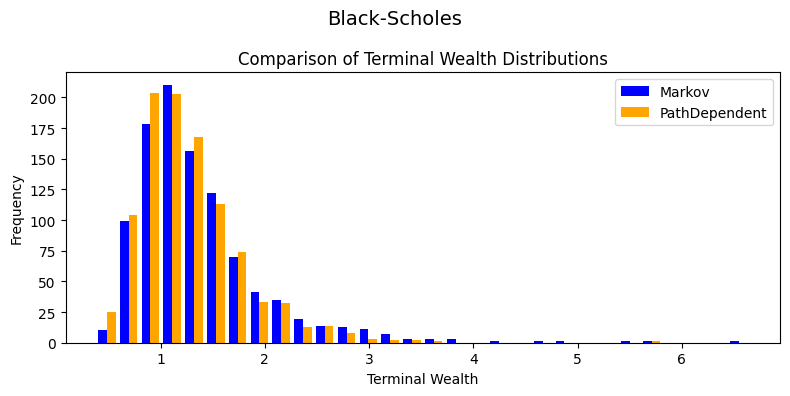

In [207]:
compare_wealth_distributions(wealth_distribution1=wealth_distribution_BS_M,wealth_distribution2=wealth_distribution_BS_PD,Title = 'Black-Scholes')

In [203]:
mean_wealth_H_M, mean_utility_H_M, wealth_distribution_H_M,price_history_H_M,wealth_history_H_M,alpha_history_H_M = trainer_H.evaluate_model(num_simulations=1000)
print('Mean Wealth Heston Model of Markovian Agent:', mean_wealth_H_M)
print('Mean utility Heston Model of Markovian Agent:', mean_utility_H_M)


Mean Wealth Heston Model of Markovian Agent: 1.0475428104400635
Mean utility Heston Model of Markovian Agent: -0.9743585586547852


In [204]:
mean_wealth_H_PD, mean_utility_H_PD, wealth_distribution_H_PD,price_history_H_PD,wealth_history_H_PD,alpha_history_H_PD = trainer_H_PD.evaluate_model(num_simulations=1000)
print('Mean Wealth Heston of Path Dependent Agent:', mean_wealth_H_PD)
print('Mean utility Heston of Path Dependent Agent:', mean_utility_H_PD)


Mean Wealth Heston of Path Dependent Agent: 1.06328547000885
Mean utility Heston of Path Dependent Agent: -0.9640788435935974


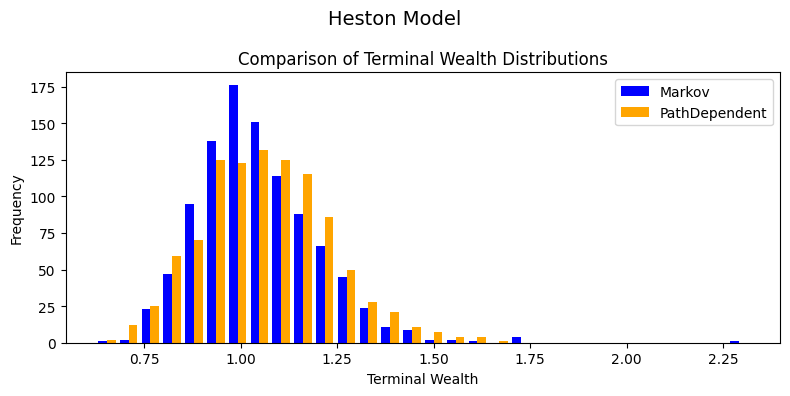

In [208]:
compare_wealth_distributions(wealth_distribution1=  wealth_distribution_H_M,wealth_distribution2=wealth_distribution_H_PD,Title = 'Heston Model')

In [200]:
mean_wealth_CEV_M, mean_utility_CEV_M, wealth_distribution_CEV_M,price_history_CEV_M,wealth_history_CEV_M,alpha_history_CEV_M = trainer_CEV.evaluate_model(num_simulations=1000)
print('Mean Wealth CEV Model of Markovian Agent:', mean_wealth_CEV_M)
print('Mean utility CEV Model of Markovian Agent:', mean_utility_CEV_M)

Mean Wealth CEV Model of Markovian Agent: 1.3558025360107422
Mean utility CEV Model of Markovian Agent: -0.8540783524513245


In [201]:
mean_wealth_CEV_PD, mean_utility_CEV_PD, wealth_distribution_CEV_PD,price_history_CEV_PD,wealth_history_CEV_PD,alpha_history_CEV_PD = trainer_CEV_PD.evaluate_model(num_simulations=1000)
print('Mean Wealth CEV Model of Path Dependent Agent:', mean_wealth_CEV_PD)
print('Mean utility CEV Model of Path Dependent Agent:', mean_utility_CEV_PD)


Mean Wealth CEV Model of Path Dependent Agent: 1.520746111869812
Mean utility CEV Model of Path Dependent Agent: -0.811943769454956


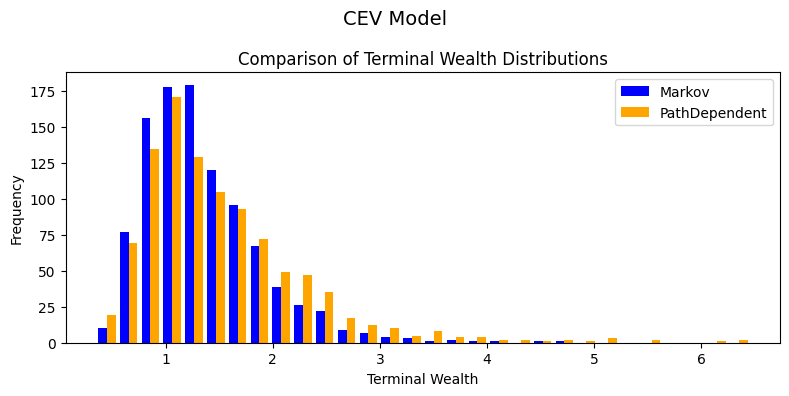

In [209]:
compare_wealth_distributions(wealth_distribution1=wealth_distribution_CEV_M,wealth_distribution2=wealth_distribution_CEV_PD,Title = 'CEV Model')